# Quanten-Hall-Effekt

In [ ]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
#import scipy.constants as const
#from scipy.optimize import least_squares
from scipy.stats import linregress
#import os

## 2.2 Messung der Supraleiter-Sprungtemperatur

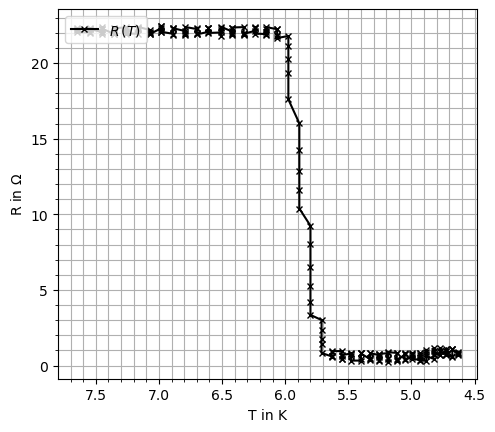

In [ ]:
sprungtemp = np.loadtxt('../Messdaten/01122025_QHE/Sprungtemperatur_log.dat', delimiter='\t', usecols=(1,7), skiprows=2450, max_rows=200)
# liest von 2450 bis 2650 ein, da ungefähr bei 2500 der Sprung stattfindet und nimmt die Spalten für Temperatur und Widerstand
T = sprungtemp[:,0]
R = sprungtemp[:,1]


# plotten
fig, (ax1) = plt.subplots(1,1,sharex=True, gridspec_kw={'hspace':0.0}, figsize=(5.4,4.8)) #layout='constrained')
ax1.plot(T, R, 'x-k', ms=4, label=r'$R\,(T)$')
ax1.xaxis.set_inverted(True)
ax1.set_xlabel('T in K')
ax1.set_ylabel(r'R in $\Omega$')
ax1.legend(loc=2)
ax1.grid(which='both')
ax1.minorticks_on()
plt.show()

# 2.3. Messung des Quanten-Hall-Effektes

Hall-Konstante: $A_\mathrm{H}=(nq)^{-1}$  
Hall-Widerstand: $R_\mathrm{xy}=\frac{B}{nqd}$ mit Feldstärke $B$, dicke der Probe parallel zu $\vec{B}$, $d$ und Ladungsträgerdichte $n$.

In [63]:
def derive(x, y, step=1):
    x, y = list(x), list(y)
    x_new, y_new, x_shifted = [], [], []
    for i, val in enumerate(x):
        if i%step == 0:
            x_new.append(val)
    for i, val in enumerate(y):
        if i % step == 0:
            y_new.append(val)
    x_new = np.array(x_new)
    y_new = np.array(y_new)
    der = np.insert(np.diff(y_new)/np.diff(x_new), 0, np.nan)
    width_list = []
    for i in range(len((x_new))):
        width = abs(x_new[i]-x_new[i-1]) # width between two values i and i-1 doesnt work for i=0
        width_list.append(width)
        x_shifted.append(x_new[i] - (width/2))
    return (x_shifted, width_list), y_new, der

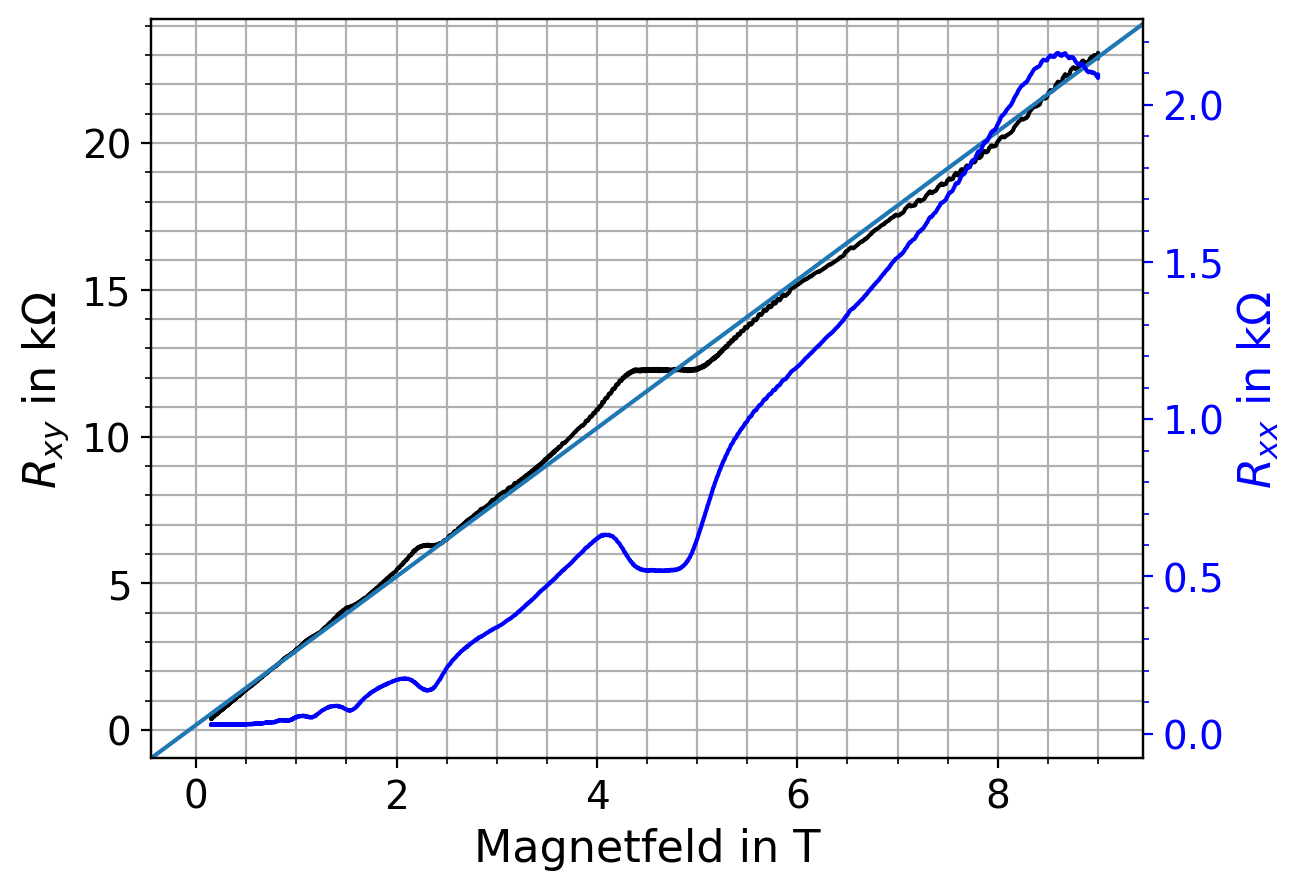

In [71]:
# Grafik Längs- und Hallwiderstand
t = []
for ti in np.loadtxt('../Messdaten/01122025_QHE/Hall_Messung_log_runter.dat', skiprows=26, delimiter='\t', usecols=0, dtype=str):
    t.append(dt.datetime(2025, 12, 1, int(ti.split(':')[0]), int(ti.split(':')[1]), int(ti.split(':')[2])))
data = np.loadtxt('../Messdaten/01122025_QHE/Hall_Messung_log_runter.dat', skiprows=26, delimiter='\t', usecols=[2, 10, 11])
B = data[:,0]
Rxy = data[:,1]/1e3
Rxx = data[:,2]/1e3
t = np.array(t)

# fit Gerade an Rxy(B)
fit = linregress(B, Rxy)
slope = fit.slope
inter = fit.intercept

fig, ax = plt.subplots(dpi=200)
ax2 = ax.twinx()
ax.plot(B, Rxy, '-k', label=r"$R_{xy}$")
ax2.plot(B, Rxx, '-b', label=r"$R_{xx}$")
ax.axline((0,inter), slope=slope)

#ax.plot(B, derive(B, Rxy)[1])

ax.set_ylabel(r'$R_{xy}$ in k$\Omega$', fontsize=16)
ax2.set_ylabel(r'$R_{xx}$ in k$\Omega$', fontsize=16, color='b')
ax.set_xlabel('Magnetfeld in T', fontsize=16)

ax.tick_params(labelsize=14)
ax2.tick_params(axis='y', which='both', labelsize=14, labelcolor='b', color='b')


ax.minorticks_on()
ax2.minorticks_on()
ax.grid(which='both')
plt.show()

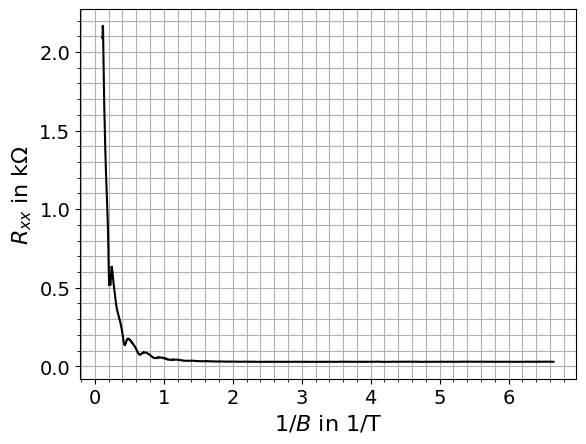

In [74]:
# Längswiderstand über inversem Magnetfeld
data = np.loadtxt('../Messdaten/01122025_QHE/Hall_Messung_log_runter.dat', skiprows=26, delimiter='\t', usecols=[2, 10, 11])
B = data[:,0]
Rxx = data[:,2]/1e3

fig, ax = plt.subplots()
ax.plot(1/B, Rxx, '-k', label=r"$R_{xy}$")

ax.set_ylabel(r'$R_{xx}$ in k$\Omega$', fontsize=16)
ax.set_xlabel(r'1/$B$ in 1/T', fontsize=16)

ax.tick_params(labelsize=14)

ax.minorticks_on()
ax.grid(which='both')
plt.show()
